In [17]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

In [18]:
carpeta = 'images/'
archivos = os.listdir(carpeta)

def draw_images(img,template):
    plt.figure(figsize=(12,5))
    plt.subplot(121)
    plt.imshow(template, cmap='gray')
    plt.title('Template')
    plt.axis('off')
    plt.subplot(122)
    plt.imshow(img, cmap='gray')
    plt.title('Imagen')
    plt.axis('off')
    plt.show()


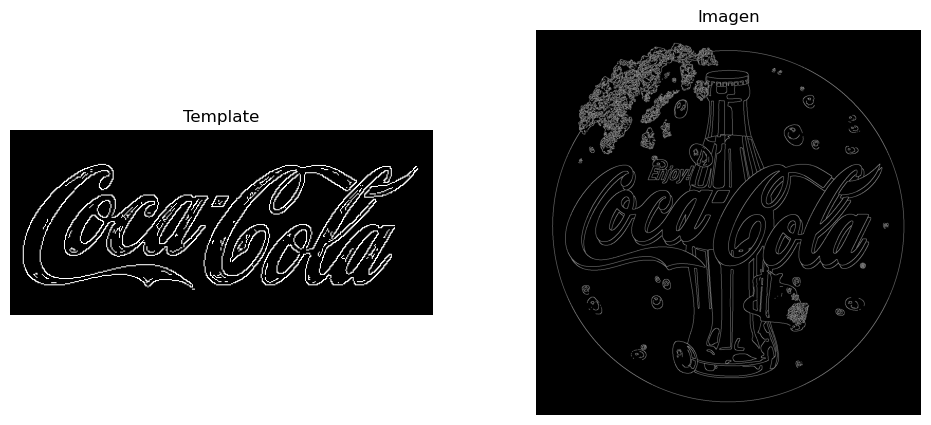

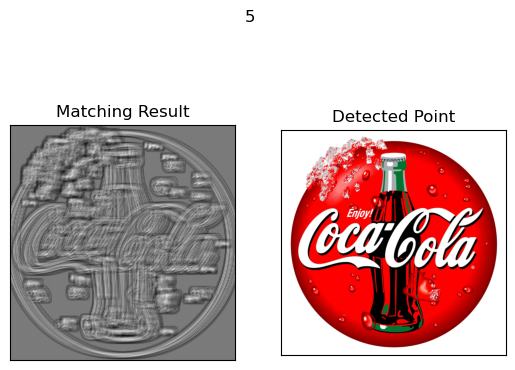

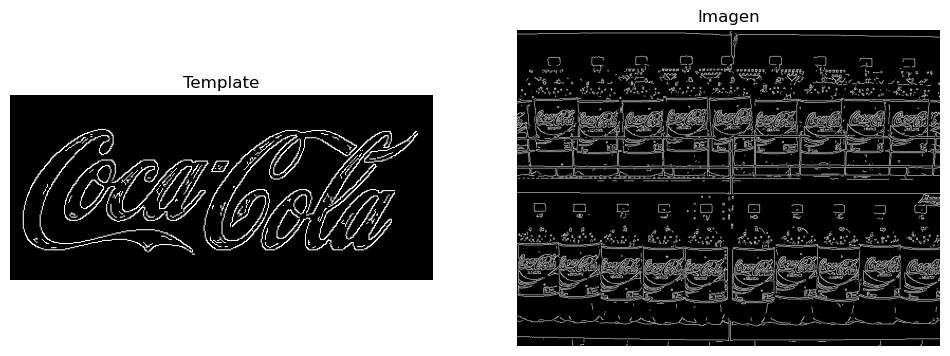

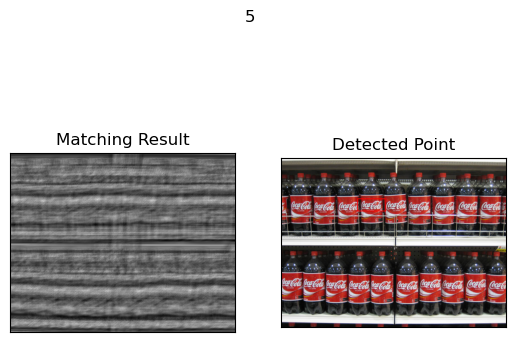

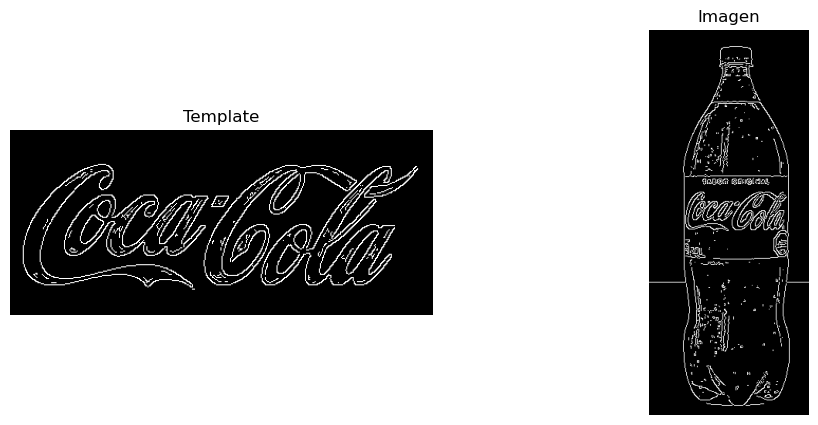

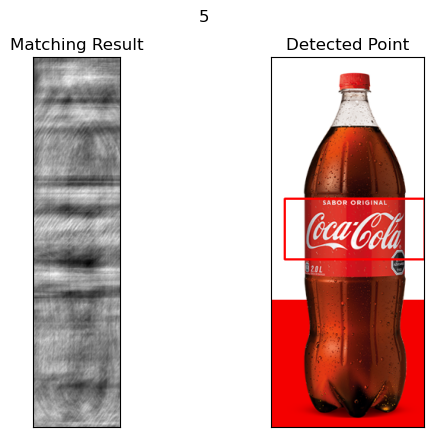

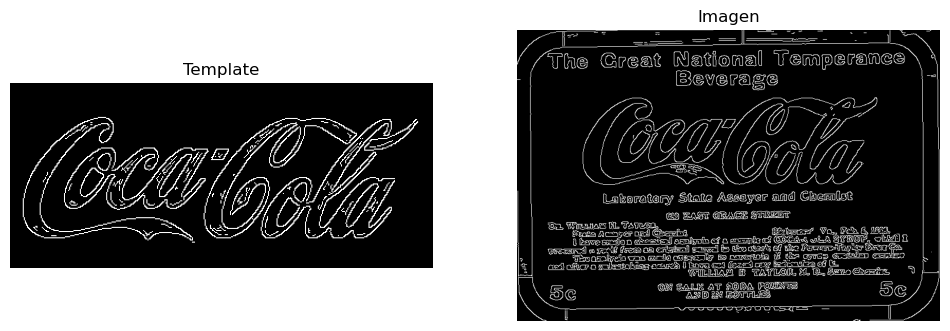

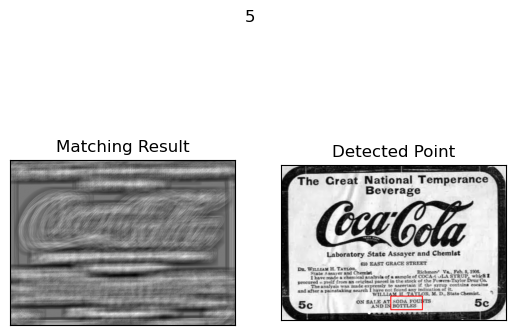

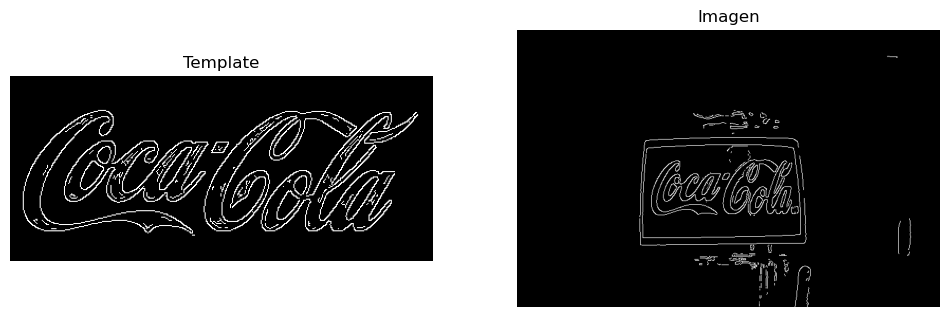

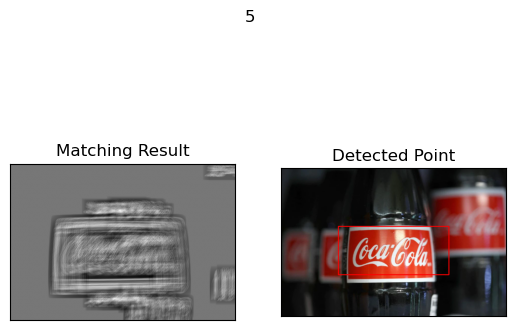

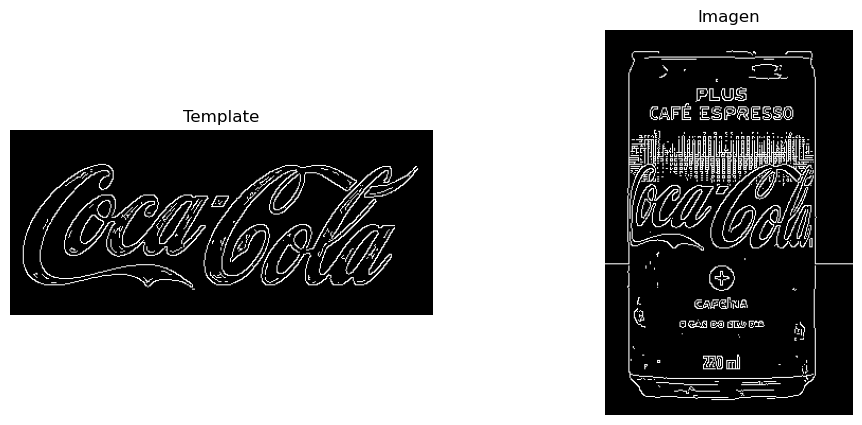

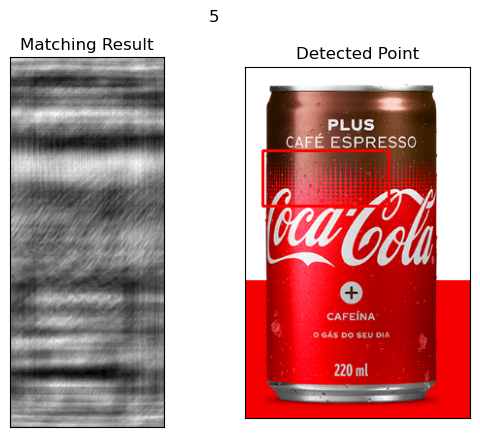

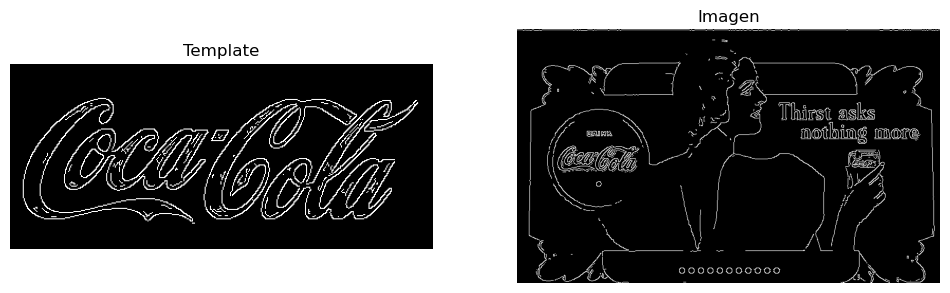

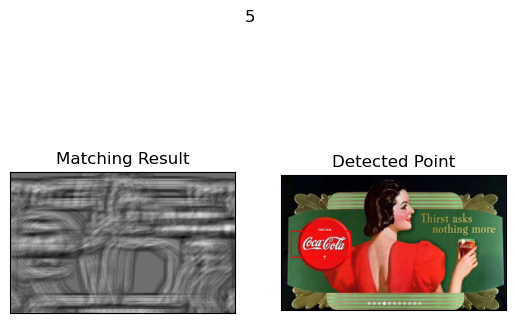

In [19]:

method = cv.TM_CCOEFF_NORMED

for archivo in archivos:
    #Cargo imagen
    img = cv.imread(carpeta + archivo)
    img_rgb= cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img_borders = cv.Canny(img, 220, 260)
    #Cargo template
    template = cv.imread('template/pattern.png', 0)
    template = cv.Canny(template, 30, 90)
    h, w = template.shape
    draw_images(img_borders,template)
    w, h = template.shape[::-1]
# Aplicamos la coincidencia de patrones
#--------------------------------------
    img_salida = img_rgb.copy()
    best_score = -1
    best_loc = None
    best_scale = None
    scales = np.linspace(0.25, 4.0 , 5)
    for s in scales:
    # Redimensionamos la imagen

        resized = cv.resize(img_borders, None, fx=s, fy=s)
        if(resized.shape[0] < template.shape[0] or resized.shape[1] < template.shape[1]):
            continue
        res = cv.matchTemplate(resized, template, method)
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
    
    # Encontramos los valores máximos y mínimos
        if  max_val > best_score:
            best_score = max_val
            best_loc = max_loc
            best_scale = s

    top_left = (int(best_loc[0] / best_scale), int(best_loc[1] / best_scale))
    bottom_right = (top_left[0] + int(w/best_scale), top_left[1] + int(h / best_scale))


    cv.rectangle(img_salida,top_left, bottom_right, 255, 2)
    
    # Graficamos el procesamiento y la salida
    #----------------------------------------
    plt.figure()
    
    # Resultado de coincidencia
    plt.subplot(121),plt.imshow(res,cmap = 'gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    
    # Imagen original con recuadros
    plt.subplot(122),plt.imshow(img_salida)
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    
    plt.suptitle(method)
    plt.show()

### Múltiples detecciones en la imagen coca_multi.png

Para buscar varios logos en la misma imagen: recorremos escalas, nos quedamos con los puntos que superan un umbral y despues aplicamos NMS para no dibujar muchas cajas repetidas sobre el mismo logo

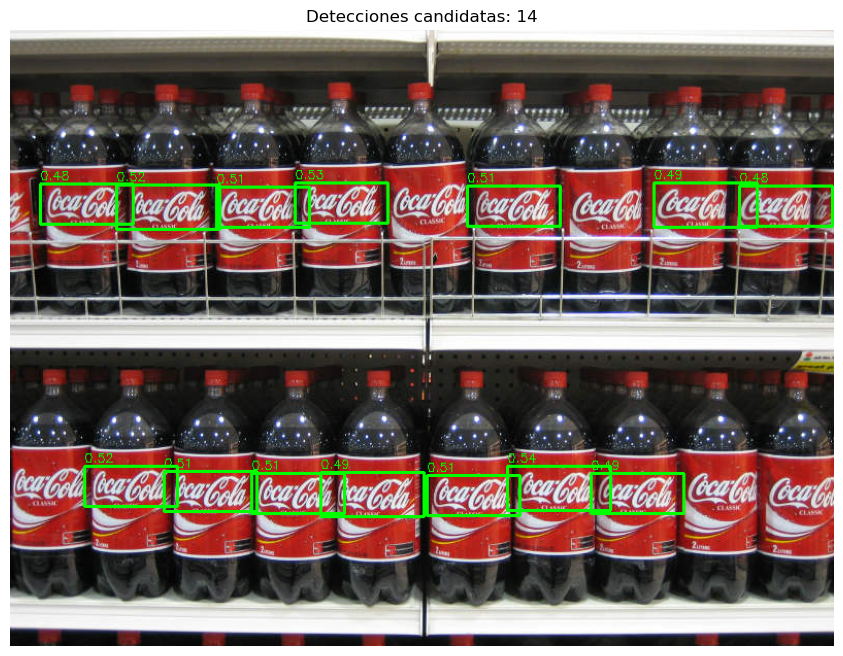

01. box=[482, 423, 100, 43] score=0.535
02. box=[276, 148, 90, 39] score=0.526
03. box=[103, 150, 100, 43] score=0.524
04. box=[72, 423, 90, 39] score=0.520
05. box=[234, 430, 90, 39] score=0.515
06. box=[404, 432, 90, 39] score=0.513
07. box=[149, 428, 90, 39] score=0.513
08. box=[200, 152, 90, 39] score=0.512
09. box=[443, 151, 90, 39] score=0.505
10. box=[301, 429, 100, 43] score=0.492
11. box=[563, 430, 90, 39] score=0.492
12. box=[624, 148, 100, 43] score=0.489
13. box=[707, 151, 90, 39] score=0.484
14. box=[29, 149, 90, 39] score=0.482


In [20]:
def prepararBinarioMulti(imgGray, esTemplate=False):
    if esTemplate:
        # En el template las letras rojas quedan oscuras en gris, por eso invertimos.
        _, binImg = cv.threshold(imgGray, 180, 255, cv.THRESH_BINARY_INV)
    else:
        # En las botellas el logo se ve blanco, nos quedamos con esas zonas claras.
        _, binImg = cv.threshold(imgGray, 180, 255, cv.THRESH_BINARY)

    kernel = np.ones((2, 2), np.uint8)
    binImg = cv.morphologyEx(binImg, cv.MORPH_OPEN, kernel)
    return binImg


def detectarMultiples(imgGray, templateGray, umbral=0.48, maxDet=14):
    imgProc = prepararBinarioMulti(imgGray, esTemplate=False)
    templateProc = prepararBinarioMulti(templateGray, esTemplate=True)
    escalasMulti = np.linspace(0.10, 0.50, 17)

    boxes = []
    scores = []

    for escala in escalasMulti:
        nuevoW = max(8, int(templateProc.shape[1] * escala))
        nuevoH = max(8, int(templateProc.shape[0] * escala))

        if nuevoW >= imgProc.shape[1] or nuevoH >= imgProc.shape[0]:
            continue

        templateEsc = cv.resize(templateProc, (nuevoW, nuevoH), interpolation=cv.INTER_AREA)
        res = cv.matchTemplate(imgProc, templateEsc, cv.TM_CCOEFF_NORMED)
        ys, xs = np.where(res >= umbral)

        for x, y in zip(xs, ys):
            boxes.append([int(x), int(y), int(nuevoW), int(nuevoH)])
            scores.append(float(res[y, x]))

    idxs = cv.dnn.NMSBoxes(boxes, scores, umbral, 0.30)
    if len(idxs) == 0:
        return []

    idxs = np.array(idxs).reshape(-1).tolist()
    detecciones = [(boxes[i], scores[i]) for i in idxs]
    detecciones = sorted(detecciones, key=lambda item: item[1], reverse=True)
    return detecciones[:maxDet]


imgMulti = cv.imread(carpeta + 'coca_multi.png')
imgMultiRgb = cv.cvtColor(imgMulti, cv.COLOR_BGR2RGB)
imgMultiGray = cv.cvtColor(imgMulti, cv.COLOR_BGR2GRAY)
detecciones = detectarMultiples(imgMultiGray, templateBase, umbral=0.48, maxDet=14)

imgMultiSalida = imgMultiRgb.copy()
for box, score in detecciones:
    x, y, boxW, boxH = box
    cv.rectangle(imgMultiSalida, (x, y), (x + boxW, y + boxH), (0, 255, 0), 2)
    cv.putText(imgMultiSalida, f'{score:.2f}', (x, max(12, y - 4)), cv.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

plt.figure(figsize=(13, 8))
plt.imshow(imgMultiSalida)
plt.title(f'Detecciones candidatas: {len(detecciones)}')
plt.axis('off')
plt.show()

for idx, (box, score) in enumerate(detecciones, start=1):
    print(f'{idx:02d}. box={box} score={score:.3f}')